In [21]:
import os
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [3]:
name2anno = {
    **json.load(open('/mnt/data/projects/bladder_neck/anno/name2anno.json')),
    **json.load(open('/mnt/data/projects/bladder_neck/anno/name2anno_demo.json'))
}

In [4]:
for k, v in name2anno.items():
    print(k, v)
    break

HXJOFXXZ3L_00-01-19_00-01-23_2377.jpg {'最佳切割线': [[41.40625, 54.365079365079374], [42.745535714285715, 53.571428571428584], [44.19642857142857, 53.174603174603185], [45.64732142857143, 52.976190476190474], [46.875, 53.37301587301588], [47.99107142857143, 54.16666666666667]], '最远切割线': [[41.74107142857143, 58.92857142857143], [42.96875, 58.333333333333336], [44.19642857142857, 58.333333333333336], [45.535714285714285, 58.333333333333336], [46.875, 58.73014863819592], [48.325895715751265, 59.52380279583432]], '前列腺': [[43.30357142857143, 43.05555555555556], [40.29017857142857, 45.436507936507944], [37.723214285714285, 48.41273878054965], [37.05357142857143, 51.1904761904762], [36.495535714285715, 53.76984126984128], [37.611607142857146, 56.34920634920636], [39.50892857142857, 55.75396825396825], [41.85267857142857, 52.77777777777778], [44.642857142857146, 51.587301587301596], [48.10267857142857, 52.38095238095239], [49.776785714285715, 54.56349206349207], [51.00446428571429, 54.563492063492

In [5]:
train = [x.strip() for x in open('/mnt/data/projects/bladder_neck/anno/split/v1/train')]
test = [x.strip() for x in open('/mnt/data/projects/bladder_neck/anno/split/v1/test')]
len(train), len(test), train[0]

(16, 4, 'JVl94bsOts')

In [6]:
train_name2anno = {}
test_name2anno = {}
for name, anno in name2anno.items():
    video = name.split('_')[0]
    if video in test:
        test_name2anno[name] = anno
    else:
        train_name2anno[name] = anno

len(train_name2anno), len(test_name2anno)

(2223, 393)

In [7]:
with open('/mnt/data/projects/bladder_neck/anno/split/v1/train_name2anno.json', 'w') as f:
    json.dump(train_name2anno, f)

with open('/mnt/data/projects/bladder_neck/anno/split/v1/test_name2anno.json', 'w') as f:
    json.dump(test_name2anno, f)

# 1. 处理分割形式

- 坐标除以100
- 最佳切割线和最远切割线围成区域

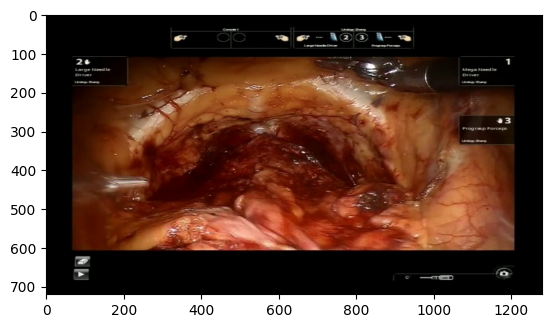

In [9]:
img = cv2.imread('/mnt/data/datastore/processed/hos301/RadicalProstatectomy/formal_label/batch1/HXJOFXXZ3L_00-01-19_00-01-23_2377.jpg')
plt.imshow(img[:,:,::-1])

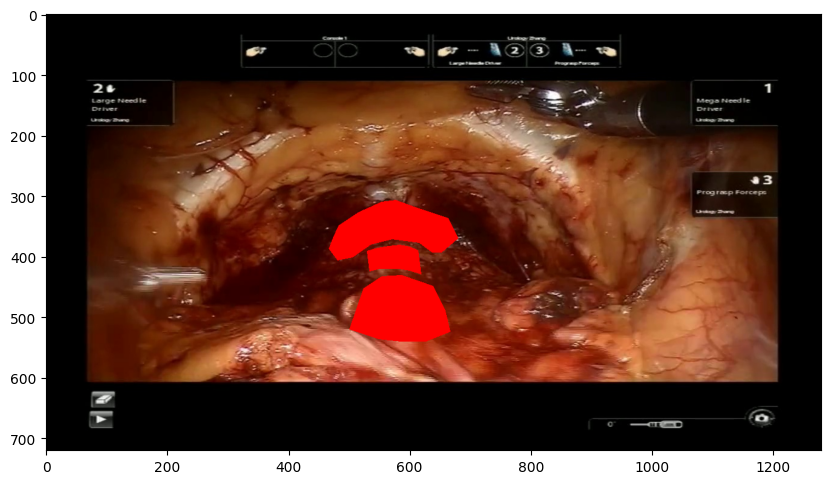

In [29]:
for k, v in train_name2anno.items():
    if not ('最佳切割线' in v and '最远切割线' in v and '前列腺' in v and '膀胱' in v):
        continue
    best_area = v['最佳切割线']
    last_area = v['最远切割线'][::-1]
    area = best_area + last_area
    
    area = np.array([[round(w*x[0]/100), round(h*x[1]/100)] for x in area])
    prostate = np.array([[round(w*x[0]/100), round(h*x[1]/100)] for x in v['前列腺']])
    bladder = np.array([[round(w*x[0]/100), round(h*x[1]/100)] for x in v['膀胱']])
    
    img1 = img.copy()
    cv2.drawContours(img1, [area], 0, (0, 0, 255), -1)
    cv2.drawContours(img1, [prostate], 0, (0, 0, 255), -1)
    cv2.drawContours(img1, [bladder], 0, (0, 0, 255), -1)
    plt.figure(figsize=(10, 8))
    plt.imshow(img1[:,:,::-1])
    break

In [11]:
h, w = img.shape[:2]

In [16]:
train_name2anno_seg = {}
for k, v in train_name2anno.items():
    if not ('最佳切割线' in v and '最远切割线' in v and '前列腺' in v and '膀胱' in v):
        continue
    best_area = v['最佳切割线']
    last_area = v['最远切割线'][::-1]
    area = best_area + last_area
    area = [[x[0]/100, x[1]/100] for x in area]
    prostate = [[x[0]/100, x[1]/100] for x in v['前列腺']]
    bladder = [[x[0]/100, x[1]/100] for x in v['膀胱']]
    train_name2anno_seg[k] = {
        'prostate': prostate,
        'cutting_area': area,
        'bladder': bladder
    }
    
    
    # area = np.array([[round(w*x[0]/100), round(h*x[1]/100)] for x in area])
    # prostate = np.array([[round(w*x[0]/100), round(h*x[1]/100)] for x in v['前列腺']])
    # bladder = np.array([[round(w*x[0]/100), round(h*x[1]/100)] for x in v['膀胱']])
    
    # img1 = img.copy()
    # cv2.drawContours(img1, [area], 0, (0, 0, 255), -1)
    # cv2.drawContours(img1, [prostate], 0, (0, 0, 255), -1)
    # cv2.drawContours(img1, [bladder], 0, (0, 0, 255), -1)
    # plt.imshow(img1[:,:,::-1])
    # break

In [17]:
test_name2anno_seg = {}
for k, v in test_name2anno.items():
    if not ('最佳切割线' in v and '最远切割线' in v and '前列腺' in v and '膀胱' in v):
        continue
    best_area = v['最佳切割线']
    last_area = v['最远切割线'][::-1]
    area = best_area + last_area
    area = [[x[0]/100, x[1]/100] for x in area]
    prostate = [[x[0]/100, x[1]/100] for x in v['前列腺']]
    bladder = [[x[0]/100, x[1]/100] for x in v['膀胱']]
    test_name2anno_seg[k] = {
        'prostate': prostate,
        'cutting_area': area,
        'bladder': bladder
    }

In [18]:
for k, v in train_name2anno_seg.items():
    print(k, v)
    break

HXJOFXXZ3L_00-01-19_00-01-23_2377.jpg {'prostate': [[0.4330357142857143, 0.4305555555555556], [0.4029017857142857, 0.4543650793650794], [0.37723214285714285, 0.4841273878054965], [0.3705357142857143, 0.511904761904762], [0.36495535714285715, 0.5376984126984128], [0.37611607142857145, 0.5634920634920636], [0.3950892857142857, 0.5575396825396826], [0.4185267857142857, 0.5277777777777778], [0.44642857142857145, 0.5158730158730159], [0.4810267857142857, 0.5238095238095238], [0.49776785714285715, 0.5456349206349207], [0.5100446428571429, 0.5456349206349207], [0.53125, 0.513888888888889], [0.5189732142857143, 0.4682539682539683], [0.4765625, 0.44246031746031744], [0.45089285714285715, 0.4265873015873016]], 'cutting_area': [[0.4140625, 0.5436507936507937], [0.42745535714285715, 0.5357142857142858], [0.4419642857142857, 0.5317460317460319], [0.4564732142857143, 0.5297619047619048], [0.46875, 0.5337301587301588], [0.4799107142857143, 0.5416666666666667], [0.48325895715751266, 0.5952380279583432

In [19]:
with open('/mnt/data/projects/bladder_neck/anno/split/v1/train_name2anno_seg.json', 'w') as f:
    json.dump(train_name2anno_seg, f)

with open('/mnt/data/projects/bladder_neck/anno/split/v1/test_name2anno_seg.json', 'w') as f:
    json.dump(test_name2anno_seg, f)

In [20]:
os.makedirs('/mnt/data2/datasets/bladder_neck/images', exist_ok=True)
os.makedirs('/mnt/data2/datasets/bladder_neck/annos/v1', exist_ok=True)

In [26]:
os.path.exists('/mnt/data/datastore/processed/BladderNeck/images_demo/Arcmdpv8sy_00-38-40_00-40-20_2358.jpg')

True

In [27]:
for name in tqdm(name2anno):
    if os.path.exists('/mnt/data2/datasets/bladder_neck/images/'+name):
        continue
    if os.path.exists('/mnt/data/datastore/processed/BladderNeck/images_demo/'+name):
        os.system(f'cp /mnt/data/datastore/processed/BladderNeck/images_demo/{name} /mnt/data2/datasets/bladder_neck/images/')
    else:
        os.system(f'cp /mnt/data/datastore/processed/hos301/RadicalProstatectomy/formal_label/batch1/{name} /mnt/data2/datasets/bladder_neck/images/')

100%|██████████| 2616/2616 [00:04<00:00, 579.33it/s]  


In [28]:
with open('/mnt/data2/datasets/bladder_neck/annos/v1/train_name2anno_seg.json', 'w') as f:
    json.dump(train_name2anno_seg, f)

with open('/mnt/data2/datasets/bladder_neck/annos/v1/test_name2anno_seg.json', 'w') as f:
    json.dump(test_name2anno_seg, f)

In [30]:
len(train_name2anno_seg), len(test_name2anno_seg)

(2148, 391)

In [33]:
'Iu5R1qLzUa_00-03-40_00-03-58_6639.jpg' in train_name2anno_seg

False

In [34]:
'Iu5R1qLzUa_00-03-40_00-03-58_6639.jpg' in test_name2anno_seg

True